In [10]:
from pathlib import Path
import csv
import json
import math
import re
from collections import defaultdict

import pandas as pd
from IPython.display import display

# Change this to the folder that contains your copied sweep folders.
# Examples:
#   ROOTS = [Path("data_4seed")]
#   ROOTS = [Path("outputs")]
#   ROOTS = [Path("outputs/food101_l40s_8q8l2f_multiseed_28641701")]
ROOTS = [Path("/Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/4_test/data_4seed")]

DATASET_FILTER = "food101"  # use "all" to keep every dataset found
OUT_DIR = Path("result_tables")
ROUND_DIGITS = 4


In [11]:
STAGE_TO_METHOD = {
    "linear_base": "Linear frozen-head baseline",
    "full_finetune": "Full fine-tune",
    "lora_dw": "LoRA depthwise adapter",
    "quad_dw": "Quadratic depthwise adapter",
    "scratch": "Scratch full training",
}

METHOD_ORDER = {
    "Linear frozen-head baseline": 0,
    "Quadratic depthwise adapter": 1,
    "LoRA depthwise adapter": 2,
    "Full fine-tune": 3,
    "Scratch full training": 4,
}

ADAPTER_RE = re.compile(
    r"^(?P<grid_id>\d+)_(?P<family>[ql])_(?P<scope>ls|all)_r(?P<rank>\d+)_"
    r"(?P<head>h[01])_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$"
)
FULL_RE = re.compile(r"^(?P<grid_id>\d+)_f_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$")
LINEAR_RE = re.compile(r"^(?P<grid_id>\d+)_lin_lr(?P<lr>[^_]+)_wd(?P<wd>.+)$")
SEED_RE = re.compile(r"^seed_(?P<seed>\d+)$")
SWEEP_RE = re.compile(r"^food101_l40s_8q8l2f_multiseed_.+$")


def safe_float(value):
    """Return float(value), or None for empty / invalid values."""
    if value is None:
        return None
    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return None
        return float(value)
    text = str(value).strip()
    if not text or text.lower() in {"none", "nan", "na", "n/a"}:
        return None
    try:
        return float(text)
    except ValueError:
        return None


def decode_num_token(token, *, kind="generic"):
    """Decode run-name tokens such as 1em3 -> 1e-3, 0p05 -> 0.05, 3e5 -> 3e-5."""
    if token is None:
        return None
    text = str(token).strip()
    if not text or text.lower() in {"none", "full"}:
        return None

    text = text.replace("p", ".")
    text = text.replace("em", "e-")

    # Full fine-tune run names were written as lr1e4/lr3e5, but the manifest
    # uses 1e-4/3e-5. Treat bare positive exponent LR tokens as compact negative exponents.
    if kind == "lr" and re.fullmatch(r"\d+(?:\.\d+)?e\d+", text):
        mantissa, exponent = text.split("e", 1)
        text = f"{mantissa}e-{exponent}"

    return safe_float(text)


def infer_sweep_name(path):
    for part in path.parts:
        if SWEEP_RE.match(part):
            return part
    for i, part in enumerate(path.parts):
        if SEED_RE.match(part) and i > 0:
            return path.parts[i - 1]
    return "unknown_sweep"


def infer_seed_from_path(path):
    for part in path.parts:
        m = SEED_RE.match(part)
        if m:
            return m.group("seed")
    return None


def infer_seed_from_metrics(metrics):
    base = metrics.get("base_checkpoint")
    if base:
        m = re.search(r"(?:^|/)seed_(\d+)(?:/|$)", str(base))
        if m:
            return m.group(1)
    return None


def infer_run_name(path):
    parts = path.parts
    for i, part in enumerate(parts):
        if SEED_RE.match(part) and i + 1 < len(parts):
            return parts[i + 1]
    return None


def parse_run_name(run_name):
    """Infer stage/scope/rank/head/lr/wd from the run folder name."""
    info = {
        "grid_id": None,
        "family": None,
        "scope_from_name": None,
        "rank_from_name": None,
        "train_head_from_name": None,
        "lr_from_name": None,
        "weight_decay_from_name": None,
    }
    if not run_name:
        return info

    m = ADAPTER_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "quad_dw" if g["family"] == "q" else "lora_dw",
            "scope_from_name": "last_stage" if g["scope"] == "ls" else "all",
            "rank_from_name": int(g["rank"]),
            "train_head_from_name": "yes" if g["head"] == "h1" else "no",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    m = FULL_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "full_finetune",
            "scope_from_name": "all",
            "rank_from_name": "full",
            "train_head_from_name": "full",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    m = LINEAR_RE.match(run_name)
    if m:
        g = m.groupdict()
        info.update({
            "grid_id": g["grid_id"],
            "family": "linear_base",
            "scope_from_name": "none",
            "rank_from_name": "none",
            "train_head_from_name": "head_only",
            "lr_from_name": decode_num_token(g["lr"], kind="lr"),
            "weight_decay_from_name": decode_num_token(g["wd"], kind="weight_decay"),
        })
        return info

    return info


In [12]:
def read_manifest(path):
    """Read one manifest.tsv produced by the sweep script."""
    rows = []
    sweep_name = infer_sweep_name(path)
    with path.open("r", newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for raw in reader:
            if not raw or not raw.get("run_name"):
                continue
            row = {
                "seed": str(raw.get("seed", "")).strip(),
                "run_name": str(raw.get("run_name", "")).strip(),
                "stage": str(raw.get("stage", "")).strip(),
                "scope": str(raw.get("scope", "")).strip(),
                "rank": str(raw.get("rank", "")).strip(),
                "train_head": str(raw.get("train_head", "")).strip(),
                "lr": str(raw.get("lr", "")).strip(),
                "weight_decay": str(raw.get("weight_decay", "")).strip(),
                "output_dir": str(raw.get("output_dir", "")).strip(),
                "manifest_path": str(path),
                "sweep_name": sweep_name,
            }
            rows.append(row)
    return rows


def load_manifests(roots):
    manifest_rows = []
    for root in roots:
        root = Path(root).expanduser()
        if root.exists():
            manifest_rows.extend(row for p in root.rglob("manifest.tsv") for row in read_manifest(p))

    by_sweep_seed_run = {}
    by_seed_run = {}
    for row in manifest_rows:
        by_sweep_seed_run[(row["sweep_name"], row["seed"], row["run_name"])] = row
        by_seed_run[(row["seed"], row["run_name"])] = row
    return manifest_rows, by_sweep_seed_run, by_seed_run


def find_metrics_files(roots):
    """Find every metrics.json under each root."""
    files = []
    seen = set()
    for root in roots:
        root = Path(root).expanduser()
        if not root.exists():
            print(f"[warning] root does not exist: {root}")
            continue
        candidates = [root] if root.is_file() and root.name == "metrics.json" else list(root.rglob("metrics.json"))
        for path in candidates:
            resolved = path.resolve()
            if resolved not in seen:
                files.append(path)
                seen.add(resolved)
    return sorted(files)


def read_json(path):
    with path.open("r") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"{path} is not a JSON object")
    return data


def get_metric_array(metrics, key):
    value = metrics.get(key, [])
    if not isinstance(value, list):
        return []
    out = []
    for item in value:
        number = safe_float(item)
        if number is not None:
            out.append(number)
    return out


def last_or_none(values):
    return values[-1] if values else None


def best_max(values):
    if not values:
        return None, None
    idx, value = max(enumerate(values), key=lambda item: item[1])
    return value, idx + 1


def best_min(values):
    if not values:
        return None, None
    idx, value = min(enumerate(values), key=lambda item: item[1])
    return value, idx + 1


In [13]:
def build_run_row(metrics_path, metrics, by_sweep_seed_run, by_seed_run):
    sweep_name = infer_sweep_name(metrics_path)
    seed = infer_seed_from_path(metrics_path) or infer_seed_from_metrics(metrics) or "unknown"
    run_name = infer_run_name(metrics_path) or "unknown_run"
    parsed = parse_run_name(run_name)

    manifest = by_sweep_seed_run.get((sweep_name, seed, run_name)) or by_seed_run.get((seed, run_name))

    stage = str(metrics.get("stage") or (manifest["stage"] if manifest else "") or parsed.get("family") or "unknown")
    dataset = str(metrics.get("dataset") or "unknown")
    method = STAGE_TO_METHOD.get(stage, stage)

    scope = manifest["scope"] if manifest else None
    rank = manifest["rank"] if manifest else None
    train_head = manifest["train_head"] if manifest else None
    lr = safe_float(manifest["lr"]) if manifest else None
    weight_decay = safe_float(manifest["weight_decay"]) if manifest else None

    scope = scope or parsed.get("scope_from_name")
    rank = rank if rank not in (None, "") else parsed.get("rank_from_name")
    train_head = train_head or parsed.get("train_head_from_name")
    lr = lr if lr is not None else parsed.get("lr_from_name")
    weight_decay = weight_decay if weight_decay is not None else parsed.get("weight_decay_from_name")

    # For adapter runs, the parent folder also contains scope/rank, e.g. last_stage_rank_4.
    if stage in {"lora_dw", "quad_dw"}:
        m = re.match(r"(?P<scope>last_stage|all)_rank_(?P<rank>\d+)$", metrics_path.parent.name)
        if m:
            scope = scope or m.group("scope")
            rank = rank or int(m.group("rank"))

    train_loss = get_metric_array(metrics, "train_loss")
    train_acc = get_metric_array(metrics, "train_acc")
    test_loss = get_metric_array(metrics, "test_loss")
    test_acc = get_metric_array(metrics, "test_acc")

    best_test_acc, best_test_acc_epoch = best_max(test_acc)
    best_test_loss, best_test_loss_epoch = best_min(test_loss)
    best_train_acc, best_train_acc_epoch = best_max(train_acc)

    final_test_acc = last_or_none(test_acc)
    final_train_acc = last_or_none(train_acc)
    final_test_loss = last_or_none(test_loss)
    final_train_loss = last_or_none(train_loss)

    training_time_sec = safe_float(metrics.get("training_time_sec"))
    trainable_params = safe_float(metrics.get("trainable_params"))
    total_params = safe_float(metrics.get("total_params"))
    trainable_pct = 100.0 * trainable_params / total_params if trainable_params is not None and total_params else None

    return {
        "sweep": sweep_name,
        "seed": seed,
        "dataset": dataset,
        "run_name": run_name,
        "grid_id": parsed.get("grid_id"),
        "method": method,
        "stage": stage,
        "scope": scope,
        "rank": rank,
        "train_head": train_head,
        "lr": lr,
        "weight_decay": weight_decay,
        "epochs_completed": max(len(train_loss), len(train_acc), len(test_loss), len(test_acc)),
        "final_train_loss": final_train_loss,
        "final_train_acc": final_train_acc,
        "final_test_loss": final_test_loss,
        "final_test_acc": final_test_acc,
        "best_train_acc": best_train_acc,
        "best_train_acc_epoch": best_train_acc_epoch,
        "best_test_acc": best_test_acc,
        "best_test_acc_epoch": best_test_acc_epoch,
        "best_test_loss": best_test_loss,
        "best_test_loss_epoch": best_test_loss_epoch,
        "best_minus_final_test_acc": (best_test_acc - final_test_acc) if best_test_acc is not None and final_test_acc is not None else None,
        "final_generalization_gap": (final_train_acc - final_test_acc) if final_train_acc is not None and final_test_acc is not None else None,
        "trainable_params": int(trainable_params) if trainable_params is not None else None,
        "total_params": int(total_params) if total_params is not None else None,
        "trainable_pct": trainable_pct,
        "training_time_sec": training_time_sec,
        "training_time_min": training_time_sec / 60.0 if training_time_sec is not None else None,
        "training_time_hr": training_time_sec / 3600.0 if training_time_sec is not None else None,
        "base_checkpoint": metrics.get("base_checkpoint"),
        "metrics_path": str(metrics_path),
    }


def build_epoch_rows(run_row, metrics):
    train_loss = get_metric_array(metrics, "train_loss")
    train_acc = get_metric_array(metrics, "train_acc")
    test_loss = get_metric_array(metrics, "test_loss")
    test_acc = get_metric_array(metrics, "test_acc")
    n = max(len(train_loss), len(train_acc), len(test_loss), len(test_acc))
    rows = []
    for i in range(n):
        rows.append({
            "sweep": run_row["sweep"],
            "seed": run_row["seed"],
            "dataset": run_row["dataset"],
            "run_name": run_row["run_name"],
            "grid_id": run_row.get("grid_id"),   # <-- add this line
            "method": run_row["method"],
            "stage": run_row["stage"],
            "scope": run_row["scope"],
            "rank": run_row["rank"],
            "train_head": run_row["train_head"],
            "lr": run_row["lr"],
            "weight_decay": run_row["weight_decay"],
            "epoch": i + 1,
            "train_loss": train_loss[i] if i < len(train_loss) else None,
            "train_acc": train_acc[i] if i < len(train_acc) else None,
            "test_loss": test_loss[i] if i < len(test_loss) else None,
            "test_acc": test_acc[i] if i < len(test_acc) else None,
            "metrics_path": run_row["metrics_path"],
        })
    return rows


In [14]:
def sort_run_dataframe(df):
    if df.empty:
        return df
    out = df.copy()
    out["_seed_sort"] = pd.to_numeric(out["seed"], errors="coerce").fillna(999999)
    out["_method_sort"] = out["method"].map(METHOD_ORDER).fillna(99)
    out["_grid_sort"] = pd.to_numeric(out["grid_id"], errors="coerce").fillna(999999)
    out = out.sort_values(["_seed_sort", "_method_sort", "_grid_sort", "run_name"]).drop(columns=["_seed_sort", "_method_sort", "_grid_sort"])
    return out.reset_index(drop=True)


def summarize_by_config(all_runs):
    if all_runs.empty:
        return pd.DataFrame()

    group_cols = ["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"]
    df = all_runs.copy()
    df["rank"] = df["rank"].astype(str)
    df["scope"] = df["scope"].astype(str)
    df["train_head"] = df["train_head"].astype(str)

    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(
            n_seeds=("seed", "nunique"),
            seeds=("seed", lambda x: ",".join(sorted(set(map(str, x)), key=lambda s: int(s) if s.isdigit() else 999999))),
            best_test_acc_mean=("best_test_acc", "mean"),
            best_test_acc_std=("best_test_acc", "std"),
            final_test_acc_mean=("final_test_acc", "mean"),
            final_test_acc_std=("final_test_acc", "std"),
            best_test_loss_mean=("best_test_loss", "mean"),
            final_test_loss_mean=("final_test_loss", "mean"),
            training_time_hr_mean=("training_time_hr", "mean"),
            trainable_params_mean=("trainable_params", "mean"),
            trainable_pct_mean=("trainable_pct", "mean"),
            run_names=("run_name", lambda x: ",".join(sorted(set(map(str, x))))),
        )
        .reset_index()
    )
    summary["best_test_acc_std"] = summary["best_test_acc_std"].fillna(0.0)
    summary["final_test_acc_std"] = summary["final_test_acc_std"].fillna(0.0)
    summary["_method_sort"] = summary["method"].map(METHOD_ORDER).fillna(99)
    summary = summary.sort_values(["_method_sort", "best_test_acc_mean"], ascending=[True, False]).drop(columns="_method_sort")
    return summary.reset_index(drop=True)


def summarize_best_by_method(summary_by_config):
    if summary_by_config.empty:
        return pd.DataFrame()
    idx = summary_by_config.groupby("method")["best_test_acc_mean"].idxmax()
    out = summary_by_config.loc[idx].sort_values("best_test_acc_mean", ascending=False)
    return out.reset_index(drop=True)


def expected_grid():
    """Fallback expected grid from the sweep scripts: 1 linear, 8 quadratic, 8 LoRA, 2 full fine-tune runs."""
    specs = [{
        "run_name": "000_lin_lr1e3_wd0p05", "stage": "linear_base", "scope": "none", "rank": "none",
        "train_head": "head_only", "lr": 1e-3, "weight_decay": 0.05,
    }]
    adapter_specs = [
        ("last_stage", 1, "no", 1e-3, 0.0),
        ("last_stage", 2, "no", 1e-3, 0.0),
        ("last_stage", 4, "no", 1e-3, 0.0),
        ("last_stage", 2, "no", 3e-4, 0.01),
        ("all", 1, "no", 3e-4, 0.0),
        ("all", 2, "no", 3e-4, 0.0),
        ("last_stage", 2, "yes", 1e-4, 0.0),
        ("all", 2, "yes", 1e-4, 0.0),
    ]
    for offset, stage, prefix in [(100, "quad_dw", "q"), (200, "lora_dw", "l")]:
        for idx, (scope, rank, head, lr, wd) in enumerate(adapter_specs, start=1):
            scope_tag = "ls" if scope == "last_stage" else "all"
            htag = "h1" if head == "yes" else "h0"
            lr_token = str(lr).replace("e-", "em").replace(".", "p")
            wd_token = str(wd).replace(".", "p")
            specs.append({
                "run_name": f"{offset + idx:03d}_{prefix}_{scope_tag}_r{rank}_{htag}_lr{lr_token}_wd{wd_token}",
                "stage": stage, "scope": scope, "rank": str(rank), "train_head": head, "lr": lr, "weight_decay": wd,
            })
    specs.extend([
        {"run_name": "301_f_lr1e4_wd0p01", "stage": "full_finetune", "scope": "all", "rank": "full", "train_head": "full", "lr": 1e-4, "weight_decay": 0.01},
        {"run_name": "302_f_lr3e5_wd0p05", "stage": "full_finetune", "scope": "all", "rank": "full", "train_head": "full", "lr": 3e-5, "weight_decay": 0.05},
    ])
    return pd.DataFrame(specs)


def missing_expected_runs(all_runs, manifest_rows):
    if all_runs.empty:
        return pd.DataFrame()

    seeds = sorted(all_runs.loc[all_runs["seed"] != "unknown", "seed"].astype(str).unique(), key=lambda x: int(x) if x.isdigit() else 999999)
    present = set(zip(all_runs["seed"].astype(str), all_runs["run_name"].astype(str)))

    expected_by_seed = defaultdict(list)
    for m in manifest_rows:
        expected_by_seed[m["seed"]].append({
            "run_name": m["run_name"], "stage": m["stage"], "scope": m["scope"], "rank": m["rank"],
            "train_head": m["train_head"], "lr": safe_float(m["lr"]), "weight_decay": safe_float(m["weight_decay"]),
        })

    fallback = expected_grid().to_dict("records")
    missing = []
    for seed in seeds:
        specs = expected_by_seed.get(seed) or fallback
        for spec in specs:
            if (seed, spec["run_name"]) not in present:
                missing.append({"seed": seed, **spec})
    return pd.DataFrame(missing)


In [15]:
def collect_experiments(roots=ROOTS, dataset_filter=DATASET_FILTER):
    roots = [Path(p).expanduser() for p in roots]
    manifest_rows, by_sweep_seed_run, by_seed_run = load_manifests(roots)
    metrics_files = find_metrics_files(roots)

    run_rows = []
    epoch_rows = []
    skipped = []

    for metrics_path in metrics_files:
        try:
            metrics = read_json(metrics_path)
        except Exception as exc:
            skipped.append((str(metrics_path), str(exc)))
            continue

        dataset = str(metrics.get("dataset") or "unknown")
        if dataset_filter.lower() != "all" and dataset.lower() != dataset_filter.lower():
            continue

        row = build_run_row(metrics_path, metrics, by_sweep_seed_run, by_seed_run)
        run_rows.append(row)
        epoch_rows.extend(build_epoch_rows(row, metrics))

    all_runs = sort_run_dataframe(pd.DataFrame(run_rows))
    epoch_history = sort_run_dataframe(pd.DataFrame(epoch_rows)) if epoch_rows else pd.DataFrame()
    summary_config = summarize_by_config(all_runs)
    summary_method = summarize_best_by_method(summary_config)
    missing = missing_expected_runs(all_runs, manifest_rows)

    print("Loaded metrics files:", len(metrics_files))
    print("Runs kept after dataset filter:", len(all_runs))
    print("Manifests found rows:", len(manifest_rows))
    if skipped:
        print("Skipped invalid metrics files:", len(skipped))
        display(pd.DataFrame(skipped, columns=["path", "reason"]))

    return all_runs, epoch_history, summary_config, summary_method, missing


all_runs, epoch_history, summary_by_config, summary_by_method, missing_expected = collect_experiments()


Loaded metrics files: 95
Runs kept after dataset filter: 95
Manifests found rows: 97


In [16]:
# Main one-row-per-run table
view_cols = [
    "seed", "run_name", "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay",
    "epochs_completed", "best_test_acc", "best_test_acc_epoch", "final_test_acc",
    "trainable_params", "trainable_pct", "training_time_hr",
]

display(all_runs[view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc": "{:.4f}",
    "final_test_acc": "{:.4f}",
    "trainable_pct": "{:.2f}",
    "training_time_hr": "{:.2f}",
}))


,seed,run_name,method,stage,scope,rank,train_head,lr,weight_decay,epochs_completed,best_test_acc,best_test_acc_epoch,final_test_acc,trainable_params,trainable_pct,training_time_hr
0,21,000_lin_lr1e3_wd0p05,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,30,0.7881,12,0.7841,77669,0.28,1.21
1,21,101_q_ls_r1_h0_lr1em3_wd0p0,Quadratic depthwise adapter,quad_dw,last_stage,1,no,1.0e-03,0,12,0.7918,2,0.7898,225792,0.80,0.49
2,21,102_q_ls_r2_h0_lr1em3_wd0p0,Quadratic depthwise adapter,quad_dw,last_stage,2,no,1.0e-03,0,12,0.7922,5,0.7883,451584,1.59,0.48
3,21,103_q_ls_r4_h0_lr1em3_wd0p0,Quadratic depthwise adapter,quad_dw,last_stage,4,no,1.0e-03,0,12,0.7920,2,0.7875,903168,3.14,0.48
4,21,104_q_ls_r2_h0_lr3em4_wd0p01,Quadratic depthwise adapter,quad_dw,last_stage,2,no,3.0e-04,0.01,12,0.7909,5,0.7898,451584,1.59,0.48
5,21,105_q_all_r1_h0_lr3em4_wd0p0,Quadratic depthwise adapter,quad_dw,all,1,no,3.0e-04,0,12,0.8080,9,0.8075,649152,2.27,1.05
6,21,106_q_all_r2_h0_lr3em4_wd0p0,Quadratic depthwise adapter,quad_dw,all,2,no,3.0e-04,0,12,0.8088,7,0.8072,1298304,4.45,1.76
7,21,107_q_ls_r2_h1_lr1em4_wd0p0,Quadratic depthwise adapter,quad_dw,last_stage,2,yes,1.0e-04,0,12,0.7933,6,0.7921,529253,1.87,0.48
8,21,108_q_all_r2_h1_lr1em4_wd0p0,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,12,0.8110,12,0.8110,1375973,4.71,1.76
9,21,201_l_ls_r1_h0_lr1em3_wd0p0,LoRA depthwise adapter,lora_dw,last_stage,1,no,1.0e-03,0,12,0.7950,5,0.7900,115200,0.41,0.48


In [17]:
# Summary across seeds for every hyperparameter configuration
summary_view_cols = [
    "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay", "n_seeds", "seeds",
    "best_test_acc_mean", "best_test_acc_std", "final_test_acc_mean", "final_test_acc_std",
    "training_time_hr_mean", "trainable_params_mean", "trainable_pct_mean", "run_names",
]

display(summary_by_config[summary_view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc_mean": "{:.4f}",
    "best_test_acc_std": "{:.4f}",
    "final_test_acc_mean": "{:.4f}",
    "final_test_acc_std": "{:.4f}",
    "training_time_hr_mean": "{:.2f}",
    "trainable_params_mean": "{:,.0f}",
    "trainable_pct_mean": "{:.2f}",
}))


,method,stage,scope,rank,train_head,lr,weight_decay,n_seeds,seeds,best_test_acc_mean,best_test_acc_std,final_test_acc_mean,final_test_acc_std,training_time_hr_mean,trainable_params_mean,trainable_pct_mean,run_names
0,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,5,"21,42,45,100,123",0.7847,0.0043,0.7826,0.0041,1.22,"77,669",0.28,000_lin_lr1e3_wd0p05
1,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,5,"21,42,45,100,123",0.8125,0.0026,0.8119,0.0021,1.83,"1,375,973",4.71,108_q_all_r2_h1_lr1em4_wd0p0
2,Quadratic depthwise adapter,quad_dw,all,2,no,3.0e-04,0,5,"21,42,45,100,123",0.8091,0.0011,0.8054,0.0030,1.83,"1,298,304",4.45,106_q_all_r2_h0_lr3em4_wd0p0
3,Quadratic depthwise adapter,quad_dw,all,1,no,3.0e-04,0,5,"21,42,45,100,123",0.8087,0.0009,0.8052,0.0028,1.06,"649,152",2.27,105_q_all_r1_h0_lr3em4_wd0p0
4,Quadratic depthwise adapter,quad_dw,last_stage,2,yes,1.0e-04,0,5,"21,42,45,100,123",0.7939,0.0013,0.7927,0.0013,0.49,"529,253",1.87,107_q_ls_r2_h1_lr1em4_wd0p0
5,Quadratic depthwise adapter,quad_dw,last_stage,2,no,1.0e-03,0,5,"21,42,45,100,123",0.7921,0.0017,0.7865,0.0023,0.49,"451,584",1.59,102_q_ls_r2_h0_lr1em3_wd0p0
6,Quadratic depthwise adapter,quad_dw,last_stage,4,no,1.0e-03,0,5,"21,42,45,100,123",0.7919,0.0012,0.7855,0.0037,0.49,"903,168",3.14,103_q_ls_r4_h0_lr1em3_wd0p0
7,Quadratic depthwise adapter,quad_dw,last_stage,2,no,3.0e-04,0.01,5,"21,42,45,100,123",0.7915,0.0011,0.7902,0.0015,0.49,"451,584",1.59,104_q_ls_r2_h0_lr3em4_wd0p01
8,Quadratic depthwise adapter,quad_dw,last_stage,1,no,1.0e-03,0,5,"21,42,45,100,123",0.7915,0.0017,0.7869,0.0019,0.49,"225,792",0.80,101_q_ls_r1_h0_lr1em3_wd0p0
9,LoRA depthwise adapter,lora_dw,all,2,yes,1.0e-04,0,5,"21,42,45,100,123",0.8154,0.0029,0.8152,0.0027,1.16,"740,069",2.59,208_l_all_r2_h1_lr1em4_wd0p0


In [18]:
# Best configuration for each method/type
method_view_cols = [
    "method", "stage", "scope", "rank", "train_head", "lr", "weight_decay", "n_seeds", "seeds",
    "best_test_acc_mean", "best_test_acc_std", "final_test_acc_mean",
    "training_time_hr_mean", "trainable_params_mean", "trainable_pct_mean", "run_names",
]

display(summary_by_method[method_view_cols].style.format({
    "lr": "{:.1e}",
    "weight_decay": "{:.3g}",
    "best_test_acc_mean": "{:.4f}",
    "best_test_acc_std": "{:.4f}",
    "final_test_acc_mean": "{:.4f}",
    "training_time_hr_mean": "{:.2f}",
    "trainable_params_mean": "{:,.0f}",
    "trainable_pct_mean": "{:.2f}",
}))


,method,stage,scope,rank,train_head,lr,weight_decay,n_seeds,seeds,best_test_acc_mean,best_test_acc_std,final_test_acc_mean,training_time_hr_mean,trainable_params_mean,trainable_pct_mean,run_names
0,Full fine-tune,full_finetune,all,full,full,3.0e-05,0.05,5,"21,42,45,100,123",0.8642,0.0027,0.8624,1.76,"27,897,797",100.00,302_f_lr3e5_wd0p05
1,LoRA depthwise adapter,lora_dw,all,2,yes,1.0e-04,0,5,"21,42,45,100,123",0.8154,0.0029,0.8152,1.16,"740,069",2.59,208_l_all_r2_h1_lr1em4_wd0p0
2,Quadratic depthwise adapter,quad_dw,all,2,yes,1.0e-04,0,5,"21,42,45,100,123",0.8125,0.0026,0.8119,1.83,"1,375,973",4.71,108_q_all_r2_h1_lr1em4_wd0p0
3,Linear frozen-head baseline,linear_base,none,none,head_only,1.0e-03,0.05,5,"21,42,45,100,123",0.7847,0.0043,0.7826,1.22,"77,669",0.28,000_lin_lr1e3_wd0p05


In [20]:
# Save all tables to disk for thesis/report work.
# This version does NOT use pandas.to_markdown(), so it does not need tabulate.
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_runs.to_csv(OUT_DIR / "all_runs.csv", index=False)
epoch_history.to_csv(OUT_DIR / "epoch_history.csv", index=False)
summary_by_config.to_csv(OUT_DIR / "summary_by_config.csv", index=False)
summary_by_method.to_csv(OUT_DIR / "summary_by_method.csv", index=False)
missing_expected.to_csv(OUT_DIR / "missing_expected_runs.csv", index=False)

def _format_markdown_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, float):
        return f"{value:.6g}"
    text = str(value)
    text = text.replace("\n", " ").replace("\r", " ")
    text = text.replace("|", "\\|")
    return text

def dataframe_to_markdown_no_tabulate(df, path, index=False):
    if index:
        df = df.reset_index()
    else:
        df = df.copy()

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    columns = [str(c).replace("|", "\\|") for c in df.columns]
    lines = []
    lines.append("| " + " | ".join(columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(columns)) + " |")

    for _, row in df.iterrows():
        values = [_format_markdown_value(row[col]) for col in df.columns]
        lines.append("| " + " | ".join(values) + " |")

    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

dataframe_to_markdown_no_tabulate(all_runs, OUT_DIR / "all_runs.md", index=False)
dataframe_to_markdown_no_tabulate(summary_by_config, OUT_DIR / "summary_by_config.md", index=False)
dataframe_to_markdown_no_tabulate(summary_by_method, OUT_DIR / "summary_by_method.md", index=False)

print(f"Saved tables to: {OUT_DIR.resolve()}")

Saved tables to: /Users/haseebshafi/Documents/GitHub/Quadratic-Neurons-vs.-ReLU-How-Much-Nonlinearity-Is-Enough/Haseeb_trials/4_test/analysis/result_tables


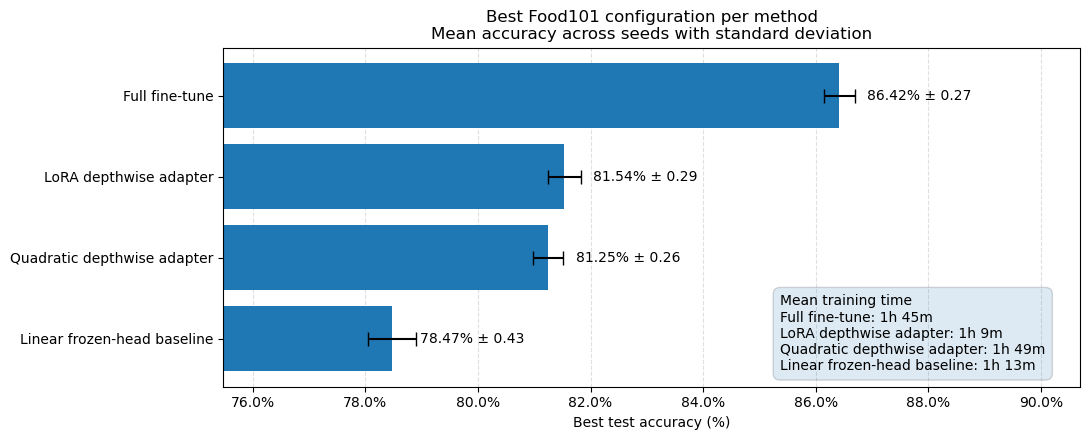

In [39]:
# Clearer plot: mean best test accuracy by method with std, exact score labels,
# and mean training time per method in a box.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

mean_col = "best_test_acc_mean"
std_col = "best_test_acc_std"
time_col = "training_time_sec"

plot_df = summary_by_method.copy()

# Convert 0.81-style accuracies to 81%-style values automatically.
scale = 100 if plot_df[mean_col].max() <= 1.5 else 1

plot_df["score_pct"] = plot_df[mean_col] * scale
plot_df["std_pct"] = plot_df[std_col].fillna(0) * scale

# Nicer labels.
method_labels = {
    "quad_dw": "Quadratic adapter",
    "lora_dw": "LoRA",
    "full_finetune": "Full fine-tuning",
    "linear_base": "Linear base",
    "scratch": "Scratch",
}

plot_df["method_label"] = plot_df["method"].map(method_labels).fillna(plot_df["method"])

# Mean training time for the selected best configuration per method only.

selected_configs = summary_by_method[
    ["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"]
].copy()

best_config_runs = all_runs.merge(
    selected_configs,
    on=["method", "stage", "scope", "rank", "train_head", "lr", "weight_decay"],
    how="inner"
)

time_summary = (
    best_config_runs
    .dropna(subset=["training_time_sec"])
    .groupby("method")["training_time_sec"]
    .mean()
)

def format_seconds(seconds):
    if pd.isna(seconds):
        return "n/a"

    seconds = float(seconds)
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)

    if hours > 0:
        return f"{hours}h {minutes}m"
    return f"{minutes}m"

# Build text box content.
time_lines = ["Mean training time"]
for method in plot_df["method"]:
    label = method_labels.get(method, method)
    mean_time = time_summary.get(method, np.nan)
    time_lines.append(f"{label}: {format_seconds(mean_time)}")

time_text = "\n".join(time_lines)

# Sort from lowest to highest so best appears at the top.
plot_df = plot_df.sort_values("score_pct", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(4.5, 0.75 * len(plot_df))))

bars = ax.barh(
    plot_df["method_label"],
    plot_df["score_pct"],
    xerr=plot_df["std_pct"],
    capsize=5
)

ax.set_xlabel("Best test accuracy (%)")
ax.set_ylabel("")
ax.set_title("Best Food101 configuration per method\nMean accuracy across seeds with standard deviation")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Give labels enough room on the right.
right_limit = (plot_df["score_pct"] + plot_df["std_pct"]).max() + 4
left_limit = max(0, plot_df["score_pct"].min() - 3)
ax.set_xlim(left_limit, right_limit)

# Add exact score labels: mean ± std.
for bar, mean, std in zip(bars, plot_df["score_pct"], plot_df["std_pct"]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    label = f"{mean:.2f}% ± {std:.2f}"
    ax.text(
        x + 0.5,
        y,
        label,
        va="center",
        fontsize=10
    )

# Add mean training time box.
ax.text(
    0.65,
    0.04,
    time_text,
    transform=ax.transAxes,
    fontsize=10,
    va="bottom",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.15
    )
)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "best_test_accuracy_by_method_with_std_and_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

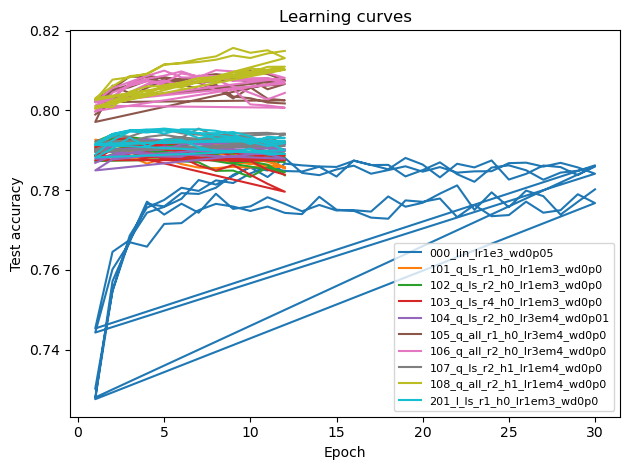

In [31]:
# Optional: inspect learning curves for selected runs.
# Edit these filters to focus on a seed/method/run.
selected_seed = None      # e.g. "45", or None for all
selected_method = None    # e.g. "Quadratic depthwise adapter", or None for all
selected_run = None       # e.g. "203_l_ls_r4_h0_lr1em3_wd0p0", or None for all

curve_df = epoch_history.copy()
if selected_seed is not None:
    curve_df = curve_df[curve_df["seed"].astype(str) == str(selected_seed)]
if selected_method is not None:
    curve_df = curve_df[curve_df["method"] == selected_method]
if selected_run is not None:
    curve_df = curve_df[curve_df["run_name"] == selected_run]

# Plot only a small number of curves to keep the figure readable.
plotted = 0
for run_name, group in curve_df.groupby("run_name"):
    plt.plot(group["epoch"], group["test_acc"], label=run_name)
    plotted += 1
    if plotted >= 10:
        break

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Learning curves")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()
